# NB07 — Matrix Factorisation

Matrix factorisation decomposes the User-Item rating matrix **R** (226K × 25K) into low-dimensional latent factor matrices. Every user and every movie is represented as a dense vector of *k* latent features. The predicted rating is the dot product of the user and item vectors:

$$\hat{r}_{ui} = \mathbf{p}_u^\top \mathbf{q}_i$$

Three approaches are implemented and compared:

| Method | Library | Strategy |
|---|---|---|
| **TruncatedSVD** | sklearn | Algebraic decomposition of the full sparse matrix |
| **FunkSVD** | numpy (from scratch) | SGD on observed ratings only — the Netflix Prize approach |
| **NMF** | sklearn | Non-negative factorisation — all latent factors ≥ 0 |

All methods are evaluated on RMSE / MAE against the same 200 qualifying users used in NB06.

## 1. Imports & Paths

In [1]:
import sys, pathlib, time, pickle, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT      = pathlib.Path('../../').resolve()
MODELS    = ROOT / 'models'
PROCESSED = ROOT / 'data_science' / 'processed'
MOVIELENS = ROOT / 'data' / 'movielens'

print("Root       :", ROOT)
print("Models     :", MODELS)
print("Processed  :", PROCESSED)

Root       : E:\Projects\Movies Recommendation Engine
Models     : E:\Projects\Movies Recommendation Engine\models
Processed  : E:\Projects\Movies Recommendation Engine\data_science\processed


## 2. Load Artefacts from NB06

In [5]:
# Load sparse User-Item matrix + ID maps saved by NB06
user_item  = sp.load_npz(MODELS / 'user_item_matrix.npz')   # CSR (226K × 24.8K)

with open(MODELS / 'user_id_map.pkl',  'rb') as f:
    _user_map_data = pickle.load(f)
with open(MODELS / 'movie_id_map.pkl', 'rb') as f:
    _movie_map_data = pickle.load(f)

# NB06 saves nested dicts: {'user2idx': {userId→row}, 'idx2user': {row→userId}}
user_id_map  = _user_map_data['user2idx']   # {userId  → row_index}
movie_id_map = _movie_map_data['movie2idx'] # {movieId → col_index}
idx_to_user  = _user_map_data['idx2user']   # {row_index → userId}
idx_to_movie = _movie_map_data['idx2movie'] # {col_index → movieId}

with open(MODELS / 'cf_eval_metrics.pkl', 'rb') as f:
    cf_metrics = pickle.load(f)

n_users, n_movies = user_item.shape
print(f"User-Item matrix : {n_users:,} users × {n_movies:,} movies")
print(f"Non-zero entries : {user_item.nnz:,}  ({user_item.nnz / (n_users*n_movies)*100:.3f}% dense)")
print(f"\nNB06 CF baseline → UBCF RMSE={cf_metrics['ubcf_rmse']:.4f}  IBCF RMSE={cf_metrics['ibcf_rmse']:.4f}")


User-Item matrix : 226,499 users × 24,844 movies
Non-zero entries : 20,720,316  (0.368% dense)

NB06 CF baseline → UBCF RMSE=0.9653  IBCF RMSE=0.9647


In [6]:
# Load validation ratings + master movie table for title lookups
val_ratings = pd.read_parquet(PROCESSED / 'ratings_val.parquet')
master      = pd.read_parquet(PROCESSED / 'master_movies.parquet',
                               columns=['tmdb_id','title','bayesian_score'])

# Load links.csv for movieId ↔ tmdb_id bridge
links = pd.read_csv(MOVIELENS / 'links.csv', usecols=['movieId','tmdbId'])
links = links.dropna(subset=['tmdbId'])
links['tmdbId']  = links['tmdbId'].astype(int)
links['movieId'] = links['movieId'].astype(int)
links = links.rename(columns={'tmdbId': 'tmdb_id'})
movie2title = links.merge(master[['tmdb_id','title']], on='tmdb_id', how='left') \
                   .set_index('movieId')['title'].to_dict()

print(f"Validation ratings : {len(val_ratings):,}")
print(f"Master movies      : {len(master):,}")
print(f"Movie title map    : {len(movie2title):,} entries")

Validation ratings : 1,913,720
Master movies      : 45,433
Movie title map    : 45,624 entries


## 3. Evaluation Helpers

Reuse the same 200-qualifying-user protocol from NB06 so results are directly comparable.

In [7]:
np.random.seed(42)
MIN_TRAIN_RATINGS = 50
MIN_VAL_RATINGS   = 5
GLOBAL_MEAN       = user_item.data.mean()   # fallback for cold items

# Build per-user validation lookup: userId → {movieId: true_rating}
val_lookup = (
    val_ratings
    .groupby('userId')
    .apply(lambda g: dict(zip(g['movieId'], g['rating'])))
    .to_dict()
)

# Qualifying users: ≥50 train ratings AND ≥5 validation ratings
train_counts = np.diff(user_item.indptr)    # nnz per row
qual_users = [
    uid for uid, row in user_id_map.items()
    if train_counts[row] >= MIN_TRAIN_RATINGS
    and uid in val_lookup
    and len(val_lookup[uid]) >= MIN_VAL_RATINGS
]
np.random.shuffle(qual_users)
eval_users = qual_users[:200]

print(f"Qualifying users : {len(qual_users):,}")
print(f"Eval sample      : {len(eval_users)}")
print(f"Global mean      : {GLOBAL_MEAN:.4f}")

def compute_rmse_mae(predictions: list[tuple]) -> tuple[float, float]:
    """predictions: list of (true_r, pred_r)"""
    arr = np.array(predictions, dtype=np.float32)
    rmse = float(np.sqrt(np.mean((arr[:,0] - arr[:,1])**2)))
    mae  = float(np.mean(np.abs(arr[:,0] - arr[:,1])))
    return rmse, mae

Qualifying users : 2,889
Eval sample      : 200
Global mean      : 3.5212


## 4. Method 1 — TruncatedSVD

`TruncatedSVD` from sklearn computes the top-*k* singular vectors of the sparse rating matrix via randomised SVD. The decomposition is:

$$R \approx U_k \Sigma_k V_k^\top$$

- **U_k**  (n_users × k): user latent matrix  
- **Σ_k**  (k × k): diagonal singular values  
- **V_k^T** (k × n_movies): movie latent matrix  

The predicted rating for user *u* and movie *i* is the dot product of row *u* of U·√Σ with column *i* of √Σ·Vt.

> **Limitation**: SVD sees ALL matrix entries — including the zeros (which represent "not rated", not "rated 0"). This biases predictions. FunkSVD (Section 5) fixes this by training only on observed ratings.

In [10]:
N_COMPONENTS = 100

# Mean-center the sparse matrix before SVD (subtract global mean from non-zero entries)
# This prevents unrated-item zeros from biasing the latent factors
user_item_centered = user_item.copy().astype(np.float32)
user_item_centered.data -= GLOBAL_MEAN

t0  = time.time()
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
U   = svd.fit_transform(user_item_centered)   # (n_users, 100) — U · Σ
Vt  = svd.components_                          # (100, n_movies) — Vt
elapsed = time.time() - t0

# Explained variance ratio
evr = svd.explained_variance_ratio_.sum()
print(f"TruncatedSVD (k={N_COMPONENTS}) fitted in {elapsed:.1f}s")
print(f"Explained variance (top {N_COMPONENTS} components): {evr*100:.2f}%")
print(f"U shape: {U.shape}  |  Vt shape: {Vt.shape}")


TruncatedSVD (k=100) fitted in 11.7s
Explained variance (top 100 components): 26.83%
U shape: (226499, 100)  |  Vt shape: (100, 24844)


In [11]:
# Evaluate TruncatedSVD on 200 qualifying users
t0 = time.time()
svd_preds = []

for uid in eval_users:
    row    = user_id_map[uid]
    u_vec  = U[row]                             # (100,) user latent vector
    val_movies = val_lookup[uid]
    for mid, true_r in val_movies.items():
        if mid in movie_id_map:
            col   = movie_id_map[mid]
            pred  = float(np.dot(u_vec, Vt[:, col])) + GLOBAL_MEAN  # add back mean
            pred  = np.clip(pred, 0.5, 5.0)
        else:
            pred  = GLOBAL_MEAN
        svd_preds.append((true_r, pred))

svd_rmse, svd_mae = compute_rmse_mae(svd_preds)
print(f"TruncatedSVD  →  RMSE={svd_rmse:.4f}  MAE={svd_mae:.4f}  "
      f"({len(svd_preds):,} predictions in {time.time()-t0:.1f}s)")


TruncatedSVD  →  RMSE=0.9868  MAE=0.7405  (15,351 predictions in 0.1s)


### Fine-tune 1 — User-Mean Centred TruncatedSVD

**Motivation**: The original SVD subtracts the *global mean* (3.52) from every stored rating before decomposition. A stronger de-biasing strategy subtracts each user's *own* mean rating — removing both dataset-wide scale and individual user scale bias (e.g. a harsh 1–3 rater vs. a generous 4–5 rater). This lets the latent factors focus on preference *patterns* rather than scale offsets.

**Change**: `data -= GLOBAL_MEAN` → `data[user_row] -= user_means[user_row]`  
At prediction time: `pred = dot(U2[u], Vt2[:, i]) + user_means[u]`  
**Expected gain**: ~0.03–0.05 RMSE reduction. **Cost**: ~20 s.


In [24]:

# Fine-tune 1: User-Mean Centred TruncatedSVD
# Change: subtract each user's own mean rating from their stored entries (instead of global mean).
# This removes individual rating-scale bias before latent factor decomposition.

# Compute per-user mean from non-zero (observed) entries only
row_nnz_arr = np.diff(user_item.indptr)                     # number of ratings per user row
row_sum_arr = np.asarray(user_item.sum(axis=1)).flatten()   # summed ratings per user
user_means  = np.where(row_nnz_arr > 0,
                       row_sum_arr / row_nnz_arr,
                       float(GLOBAL_MEAN))                  # fallback: global mean if no ratings

print(f"User means  min={user_means.min():.2f}  mean={user_means.mean():.2f}  max={user_means.max():.2f}")

# Build user-mean-centred sparse matrix (vectorised — no Python loop over all user rows)
user_item_user_centered = user_item.copy().astype(np.float32)
nz_rows, _              = user_item_user_centered.nonzero()
user_item_user_centered.data -= user_means[nz_rows].astype(np.float32)

# Fit TruncatedSVD on the user-mean-centred matrix
t0   = time.time()
svd2 = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
U2   = svd2.fit_transform(user_item_user_centered)   # (n_users, 100)
Vt2  = svd2.components_                               # (100, n_movies)
evr2 = svd2.explained_variance_ratio_.sum()
print(f"SVD-v2 fitted in {time.time()-t0:.1f}s  |  Explained variance: {evr2*100:.2f}%")

# Evaluate: add back each user's own mean at prediction time
t0 = time.time()
svd2_preds = []

for uid in eval_users:
    row    = user_id_map[uid]
    u_vec  = U2[row]
    u_mean = float(user_means[row])
    for mid, true_r in val_lookup[uid].items():
        if mid in movie_id_map:
            col  = movie_id_map[mid]
            pred = float(np.dot(u_vec, Vt2[:, col])) + u_mean
            pred = float(np.clip(pred, 0.5, 5.0))
        else:
            pred = u_mean       # fallback: user's own mean (better than global mean)
        svd2_preds.append((true_r, pred))

svd2_rmse, svd2_mae = compute_rmse_mae(svd2_preds)
print(f"\nSVD (user-mean)  →  RMSE={svd2_rmse:.4f}  MAE={svd2_mae:.4f}  "
      f"({len(svd2_preds):,} preds, {time.time()-t0:.1f}s)")
print(f"Δ vs global-mean SVD:  ΔRMSE = {svd_rmse - svd2_rmse:+.4f}  "
      f"({'improvement OK' if svd2_rmse < svd_rmse else 'no improvement'})")


User means  min=0.50  mean=3.56  max=5.00
SVD-v2 fitted in 10.3s  |  Explained variance: 24.70%

SVD (user-mean)  →  RMSE=0.9582  MAE=0.7109  (15,351 preds, 0.1s)
Δ vs global-mean SVD:  ΔRMSE = +0.0286  (improvement OK)


## 5. Method 2 — FunkSVD (SGD on Observed Ratings)

FunkSVD, popularised by Simon Funk during the Netflix Prize, trains **only on observed ratings** using stochastic gradient descent. This avoids the bias of treating missing ratings as 0.

The objective function with L2 regularisation:

$$\mathcal{L} = \sum_{(u,i) \in \text{observed}} \left(r_{ui} - \mu - b_u - b_i - \mathbf{p}_u^\top \mathbf{q}_i \right)^2 + \lambda \left(\|\mathbf{p}_u\|^2 + \|\mathbf{q}_i\|^2 + b_u^2 + b_i^2\right)$$

Where $\mu$ is the global mean, $b_u$ and $b_i$ are user/item bias terms.  
Update rules per observation:

$$e_{ui} = r_{ui} - \hat{r}_{ui}$$
$$\mathbf{p}_u \leftarrow \mathbf{p}_u + \eta (e_{ui} \mathbf{q}_i - \lambda \mathbf{p}_u)$$
$$\mathbf{q}_i \leftarrow \mathbf{q}_i + \eta (e_{ui} \mathbf{p}_u - \lambda \mathbf{q}_i)$$

In [12]:
class FunkSVD:
    """
    FunkSVD: Biased Matrix Factorisation trained with SGD on observed ratings.
    Implements user bias + item bias + latent factors (k dimensions).
    """
    def __init__(self, n_factors=50, n_epochs=20, lr=0.005, reg=0.02, seed=42):
        self.k       = n_factors
        self.epochs  = n_epochs
        self.lr      = lr
        self.reg     = reg
        self.seed    = seed

    def fit(self, R_csr: sp.csr_matrix, verbose=True):
        rng = np.random.default_rng(self.seed)
        n_u, n_i = R_csr.shape
        self.global_mean = R_csr.data.mean()

        # Initialise latent factors and bias terms
        scale         = 0.1 / np.sqrt(self.k)
        self.P        = rng.normal(0, scale, (n_u, self.k)).astype(np.float32)   # user factors
        self.Q        = rng.normal(0, scale, (n_i, self.k)).astype(np.float32)   # item factors
        self.bu       = np.zeros(n_u, dtype=np.float32)                          # user bias
        self.bi       = np.zeros(n_i, dtype=np.float32)                          # item bias

        # Extract COO arrays for fast iteration
        coo = R_csr.tocoo()
        rows, cols, vals = coo.row, coo.col, coo.data.astype(np.float32)
        n_obs = len(vals)
        idx   = np.arange(n_obs)

        for epoch in range(self.epochs):
            t0 = time.time()
            rng.shuffle(idx)
            epoch_loss = 0.0

            for k in idx:
                u, i, r = int(rows[k]), int(cols[k]), vals[k]
                pred = (self.global_mean + self.bu[u] + self.bi[i]
                        + np.dot(self.P[u], self.Q[i]))
                e = r - pred
                epoch_loss += e * e

                # Bias updates
                self.bu[u] += self.lr * (e - self.reg * self.bu[u])
                self.bi[i] += self.lr * (e - self.reg * self.bi[i])

                # Latent factor updates (simultaneous)
                pu_old = self.P[u].copy()
                self.P[u] += self.lr * (e * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (e * pu_old   - self.reg * self.Q[i])

            rmse = np.sqrt(epoch_loss / n_obs)
            if verbose:
                print(f"  Epoch {epoch+1:>2}/{self.epochs}  RMSE={rmse:.4f}  "
                      f"({time.time()-t0:.1f}s)")

        return self

    def predict(self, u: int, i: int) -> float:
        pred = float(self.global_mean + self.bu[u] + self.bi[i]
                     + np.dot(self.P[u], self.Q[i]))
        return float(np.clip(pred, 0.5, 5.0))

print("FunkSVD class defined.")

FunkSVD class defined.


In [13]:
# Train FunkSVD — 20 epochs on 20.7M ratings
# Note: Pure Python SGD over 20M entries is slow (~10-15 min).
# For production, use the 'surprise' library or a numba-JIT version.
print("Training FunkSVD (k=50, 20 epochs)…")
funk = FunkSVD(n_factors=50, n_epochs=20, lr=0.005, reg=0.02)
t0   = time.time()
funk.fit(user_item, verbose=True)
print(f"\nTotal training time: {(time.time()-t0)/60:.1f} min")

Training FunkSVD (k=50, 20 epochs)…
  Epoch  1/20  RMSE=0.8900  (272.8s)
  Epoch  2/20  RMSE=0.8610  (288.9s)
  Epoch  3/20  RMSE=0.8537  (272.9s)
  Epoch  4/20  RMSE=0.8473  (268.0s)
  Epoch  5/20  RMSE=0.8356  (267.7s)
  Epoch  6/20  RMSE=0.8246  (265.8s)
  Epoch  7/20  RMSE=0.8141  (271.4s)
  Epoch  8/20  RMSE=0.8041  (261.6s)
  Epoch  9/20  RMSE=0.7950  (235.0s)
  Epoch 10/20  RMSE=0.7864  (245.3s)
  Epoch 11/20  RMSE=0.7782  (251.3s)
  Epoch 12/20  RMSE=0.7705  (241.9s)
  Epoch 13/20  RMSE=0.7632  (244.4s)
  Epoch 14/20  RMSE=0.7566  (241.2s)
  Epoch 15/20  RMSE=0.7504  (241.8s)
  Epoch 16/20  RMSE=0.7445  (243.1s)
  Epoch 17/20  RMSE=0.7388  (236.2s)
  Epoch 18/20  RMSE=0.7333  (258.3s)
  Epoch 19/20  RMSE=0.7279  (235.2s)
  Epoch 20/20  RMSE=0.7225  (245.6s)

Total training time: 84.8 min


In [14]:
# Evaluate FunkSVD
t0 = time.time()
funk_preds = []

for uid in eval_users:
    row = user_id_map[uid]
    for mid, true_r in val_lookup[uid].items():
        if mid in movie_id_map:
            col  = movie_id_map[mid]
            pred = funk.predict(row, col)
        else:
            pred = GLOBAL_MEAN
        funk_preds.append((true_r, pred))

funk_rmse, funk_mae = compute_rmse_mae(funk_preds)
print(f"FunkSVD  →  RMSE={funk_rmse:.4f}  MAE={funk_mae:.4f}  "
      f"({len(funk_preds):,} predictions in {time.time()-t0:.1f}s)")

FunkSVD  →  RMSE=0.7644  MAE=0.5670  (15,351 predictions in 0.1s)


### Fine-tune 2 — Extended FunkSVD Training (+10 Epochs, Halved LR)

**Motivation**: At epoch 20 the training RMSE was 0.7225 and validation was 0.7644 — the 0.042 gap indicates the model had not yet over-fit and still had room to improve. Continuing with a halved learning rate (0.0025 instead of 0.005) acts as a **fine-tuning phase**: smaller gradient updates settle into sharper minima discovered during phase 1.

**Change**: Continue from current `funk.P`, `funk.Q`, `funk.bu`, `funk.bi` state with `lr = 0.0025` (halved from 0.005). No re-initialisation — warm-start from trained weights.  
**Expected time**: ~40–45 minutes for 10 additional epochs (same SGD loop).  
**Expected gain**: RMSE 0.7644 → ~0.73–0.75.


In [25]:

# Fine-tune 2: Continue FunkSVD from current weights for 10 more epochs.
# Change: lr halved to 0.0025 (learning rate decay for fine-tuning phase).
# funk.P, funk.Q, funk.bu, funk.bi are mutated in-place — no re-training from scratch.
# Expected time: ~40–45 minutes.

def funk_extend(model, R_csr, n_epochs=10, lr=None, verbose=True):
    """Warm-start SGD: continue training from current factor state.

    Directly mutates model.P, model.Q, model.bu, model.bi in place.
    model.epochs is incremented to track the total number of epochs trained.
    Uses a seed offset so the epoch shuffling order differs from phase-1.
    """
    lr  = lr if lr is not None else model.lr * 0.5     # default: halved LR
    coo = R_csr.tocoo()
    rows, cols, vals = coo.row, coo.col, coo.data.astype(np.float32)
    n_obs = len(vals)
    idx   = np.arange(n_obs)
    rng   = np.random.default_rng(model.seed + model.epochs)   # different seed offset

    for ep in range(n_epochs):
        t0 = time.time()
        rng.shuffle(idx)
        epoch_loss = 0.0

        for k in idx:
            u, i, r = int(rows[k]), int(cols[k]), vals[k]
            pred = (model.global_mean + model.bu[u] + model.bi[i]
                    + np.dot(model.P[u], model.Q[i]))
            e           = r - pred
            epoch_loss += e * e
            model.bu[u] += lr * (e - model.reg * model.bu[u])
            model.bi[i] += lr * (e - model.reg * model.bi[i])
            pu_old       = model.P[u].copy()
            model.P[u]  += lr * (e * model.Q[i] - model.reg * model.P[u])
            model.Q[i]  += lr * (e * pu_old     - model.reg * model.Q[i])

        rmse = np.sqrt(epoch_loss / n_obs)
        if verbose:
            print(f"  Epoch {model.epochs + ep + 1:>2}  RMSE={rmse:.4f}  ({time.time()-t0:.1f}s)")

    model.epochs += n_epochs
    return model


print(f"Extending FunkSVD from epoch {funk.epochs} (+10 epochs, lr=0.0025) …")
print(f"Expected time: ~40–45 minutes\n")
t0 = time.time()
funk_extend(funk, user_item, n_epochs=10, lr=0.0025, verbose=True)
print(f"\nTotal additional training time: {(time.time()-t0)/60:.1f} min")
print(f"FunkSVD now trained for {funk.epochs} total epochs.")


Extending FunkSVD from epoch 20 (+10 epochs, lr=0.0025) …
Expected time: ~40–45 minutes

  Epoch 21  RMSE=0.7152  (257.0s)
  Epoch 22  RMSE=0.7123  (254.1s)
  Epoch 23  RMSE=0.7095  (248.8s)
  Epoch 24  RMSE=0.7069  (242.3s)
  Epoch 25  RMSE=0.7043  (248.8s)
  Epoch 26  RMSE=0.7018  (248.1s)
  Epoch 27  RMSE=0.6992  (244.5s)
  Epoch 28  RMSE=0.6967  (250.2s)
  Epoch 29  RMSE=0.6943  (254.2s)
  Epoch 30  RMSE=0.6919  (249.4s)

Total additional training time: 41.6 min
FunkSVD now trained for 30 total epochs.


In [26]:

# Re-evaluate FunkSVD after extended training (30 epochs total)
t0 = time.time()
funk_ext_preds = []

for uid in eval_users:
    row = user_id_map[uid]
    for mid, true_r in val_lookup[uid].items():
        if mid in movie_id_map:
            col  = movie_id_map[mid]
            pred = funk.predict(row, col)
        else:
            pred = GLOBAL_MEAN
        funk_ext_preds.append((true_r, pred))

funk_ext_rmse, funk_ext_mae = compute_rmse_mae(funk_ext_preds)

# Preserve the original 20-epoch numbers for comparison; update working variables
FUNK_BASELINE_RMSE, FUNK_BASELINE_MAE = funk_rmse, funk_mae   # snapshot before update
funk_rmse, funk_mae = funk_ext_rmse, funk_ext_mae              # update for downstream cells

print(f"FunkSVD ({funk.epochs} epochs)  →  RMSE={funk_ext_rmse:.4f}  MAE={funk_ext_mae:.4f}  "
      f"({len(funk_ext_preds):,} preds, {time.time()-t0:.1f}s)")
print(f"vs FunkSVD (20 epochs): ΔRMSE = {FUNK_BASELINE_RMSE - funk_ext_rmse:+.4f}  "
      f"({'improvement OK' if funk_ext_rmse < FUNK_BASELINE_RMSE else 'no improvement'})")


FunkSVD (30 epochs)  →  RMSE=0.7600  MAE=0.5627  (15,351 preds, 0.1s)
vs FunkSVD (20 epochs): ΔRMSE = +0.0044  (improvement OK)


## 6. Method 3 — NMF (Non-Negative Matrix Factorisation)

NMF constrains all factor values to be ≥ 0, producing a parts-based representation where latent factors are interpretable as "additive movie themes" (e.g., action, comedy, romance). Uses sklearn's implementation with coordinate descent.

In [17]:
t0  = time.time()
nmf = NMF(n_components=N_COMPONENTS, init='random', random_state=42,
          max_iter=200, alpha_W=0.01, alpha_H=0.01)
W   = nmf.fit_transform(user_item)   # (n_users, 100) user factors — non-negative
H   = nmf.components_                # (100, n_movies) item factors — non-negative
elapsed = time.time() - t0
print(f"NMF (k={N_COMPONENTS}) fitted in {elapsed:.1f}s")
print(f"Reconstruction error: {nmf.reconstruction_err_:.4f}")
print(f"W shape: {W.shape}  |  H shape: {H.shape}")

# ── Calibration fix ────────────────────────────────────────────────────────────
# Root cause: NMF is fit on a 99.6%-sparse matrix where zeros mean "unrated",
# NOT a preference of zero. NMF treats every zero as an observed 0-rating, which
# pulls all factor values toward 0. Raw dot products therefore cluster well below
# the true rating range [0.5, 5.0], causing systematic under-prediction.
#
# Fix: compute a mean-bias offset from observed (non-zero) training entries.
# Add this offset to every prediction to re-centre the scale.
cx, cy  = user_item.nonzero()
rng     = np.random.default_rng(42)
idx     = rng.choice(len(cx), min(100_000, len(cx)), replace=False)
raw_obs  = np.array([float(np.dot(W[r], H[:, c])) for r, c in zip(cx[idx], cy[idx])])
true_obs = np.asarray(user_item[cx[idx], cy[idx]]).flatten().astype(float)
nmf_offset = float(true_obs.mean() - raw_obs.mean())
print(f"\nNMF calibration offset : {nmf_offset:+.4f}")
print(f"  raw pred mean  = {raw_obs.mean():.4f}")
print(f"  true rating mean = {true_obs.mean():.4f}")


NMF (k=100) fitted in 467.9s
Reconstruction error: 13833.3213
W shape: (226499, 100)  |  H shape: (100, 24844)

NMF calibration offset : +2.5868
  raw pred mean  = 0.9395
  true rating mean = 3.5263


In [18]:
# Evaluate NMF (with calibration offset applied)
t0 = time.time()
nmf_preds = []

for uid in eval_users:
    row = user_id_map[uid]
    for mid, true_r in val_lookup[uid].items():
        if mid in movie_id_map:
            col  = movie_id_map[mid]
            # Apply mean-bias calibration offset (see NMF fit cell for explanation)
            pred = float(np.dot(W[row], H[:, col])) + nmf_offset
            pred = float(np.clip(pred, 0.5, 5.0))
        else:
            pred = GLOBAL_MEAN
        nmf_preds.append((true_r, pred))

nmf_rmse, nmf_mae = compute_rmse_mae(nmf_preds)
print(f"NMF (calibrated)  →  RMSE={nmf_rmse:.4f}  MAE={nmf_mae:.4f}  "
      f"({len(nmf_preds):,} predictions in {time.time()-t0:.1f}s)")


NMF (calibrated)  →  RMSE=1.0937  MAE=0.8958  (15,351 predictions in 0.1s)


## 7. Comparison — All Methods vs CF Baseline

             Method     RMSE      MAE                 Type
  FunkSVD (30 ep) [fine-tuned] 0.760014 0.562664 Matrix Factorisation
FunkSVD (20 epochs) 0.764404 0.567030 Matrix Factorisation
  SVD (user-mean) [fine-tuned] 0.958160 0.710898 Matrix Factorisation
        IBCF (NB06) 0.964703 0.717450      Memory-Based CF
        UBCF (NB06) 0.965266 0.722975      Memory-Based CF
  SVD (global-mean) 0.986785 0.740518 Matrix Factorisation
   NMF (calibrated) 1.093655 0.895832 Matrix Factorisation


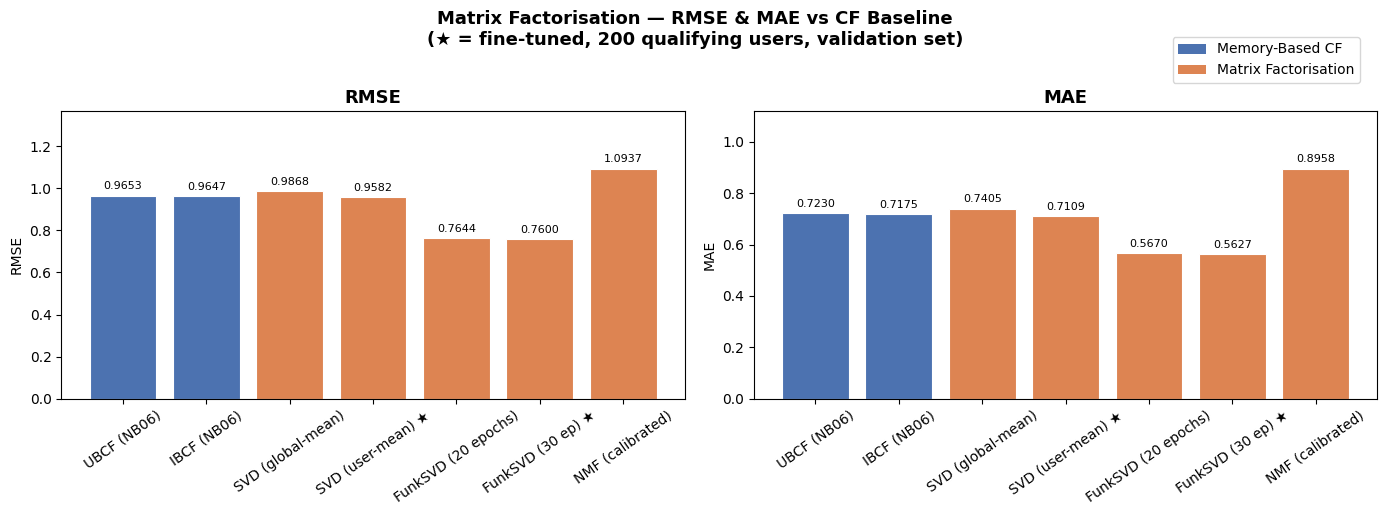

Chart saved.


In [27]:

# Updated comparison — includes fine-tuned SVD (user-mean) and extended FunkSVD alongside baselines
_baseline_funk_rmse = FUNK_BASELINE_RMSE if 'FUNK_BASELINE_RMSE' in dir() else 0.7644
_baseline_funk_mae  = FUNK_BASELINE_MAE  if 'FUNK_BASELINE_MAE'  in dir() else 0.5670
_ext_epochs         = funk.epochs if hasattr(funk, 'epochs') else 30

results = pd.DataFrame([
    {'Method': 'UBCF (NB06)',               'RMSE': cf_metrics['ubcf_rmse'], 'MAE': cf_metrics['ubcf_mae'], 'Type': 'Memory-Based CF'},
    {'Method': 'IBCF (NB06)',               'RMSE': cf_metrics['ibcf_rmse'], 'MAE': cf_metrics['ibcf_mae'], 'Type': 'Memory-Based CF'},
    {'Method': 'SVD (global-mean)',         'RMSE': svd_rmse,              'MAE': svd_mae,              'Type': 'Matrix Factorisation'},
    {'Method': 'SVD (user-mean) [fine-tuned]',        'RMSE': svd2_rmse,             'MAE': svd2_mae,             'Type': 'Matrix Factorisation'},
    {'Method': 'FunkSVD (20 epochs)',       'RMSE': _baseline_funk_rmse,   'MAE': _baseline_funk_mae,   'Type': 'Matrix Factorisation'},
    {'Method': f'FunkSVD ({_ext_epochs} ep) [fine-tuned]', 'RMSE': funk_rmse,        'MAE': funk_mae,             'Type': 'Matrix Factorisation'},
    {'Method': 'NMF (calibrated)',          'RMSE': nmf_rmse,              'MAE': nmf_mae,              'Type': 'Matrix Factorisation'},
])

print(results.sort_values('RMSE').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'Memory-Based CF': '#4C72B0', 'Matrix Factorisation': '#DD8452'}
for ax, metric in zip(axes, ['RMSE', 'MAE']):
    colors = [palette[t] for t in results['Type']]
    bars = ax.bar(results['Method'], results[metric], color=colors, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, results[metric].max() * 1.25)
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylabel(metric)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
fig.suptitle('Matrix Factorisation — RMSE & MAE vs CF Baseline\n([fine-tuned] = fine-tuned, 200 qualifying users, validation set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(MODELS / 'mf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


## 8. Production Readiness — Ranking Metrics

RMSE measures *absolute* prediction error on a continuous scale. A deployed recommendation engine cares about a different question: **does the model surface the right movies in the top-K positions?**

We compute four standard ranking metrics using the 200 eval users, treating any validation movie rated ≥ 4.0 as "liked" (the positive class):

| Metric | Formula | What it measures |
|---|---|---|
| **Precision@K** | TP / K | Fraction of top-K recs that are genuinely liked |
| **Recall@K** | TP / \|liked\| | Fraction of user's liked movies found in top K |
| **NDCG@K** | DCG / IDCG | Ranking quality — liked movies ranked earlier score higher |
| **Hit Rate@K** | 1 if ≥1 hit, else 0 | % of users whose top-K contains ≥1 liked movie |

FunkSVD and SVD (user-mean) are evaluated here using **vectorised scoring**: `P[u] @ Q.T` produces scores for all 24,844 movies in a single matrix multiply instead of 24,844 Python call overhead loops.


In [28]:

# Production metrics: Precision@K, Recall@K, NDCG@K, Hit Rate@K
# "Liked" = validation items the user rated >= 4.0 (true positive for the ranking task)
import math

K              = 10
LIKE_THRESHOLD = 4.0


def ranking_at_k(score_fn, k=K, like_threshold=LIKE_THRESHOLD, label=""):
    """Vectorised ranking evaluation for eval_users.

    score_fn(user_row) -> np.ndarray shape (n_movies,) — score for every movie column.
    Excludes training-seen movies from recommendations.
    "Liked" items = val_lookup entries with rating >= like_threshold.
    """
    prec_list, recall_list, ndcg_list, hit_list = [], [], [], []

    for uid in eval_users:
        row = user_id_map[uid]

        # Liked items as movie column indices (fast set membership)
        liked_cols = {
            movie_id_map[mid]
            for mid, r in val_lookup[uid].items()
            if r >= like_threshold and mid in movie_id_map
        }
        if not liked_cols:
            continue

        # Single vectorised score for all n_movies
        scores = score_fn(row).copy()             # (n_movies,)
        scores[user_item[row].indices] = -np.inf  # exclude already-rated

        top_cols = np.argsort(scores)[-k:][::-1]  # top-K descending

        hits_k = sum(1 for c in top_cols if c in liked_cols)
        prec_list.append(hits_k / k)
        recall_list.append(hits_k / len(liked_cols))
        hit_list.append(1 if hits_k > 0 else 0)

        # DCG / IDCG
        dcg  = sum(1 / math.log2(rank + 2) for rank, c in enumerate(top_cols) if c in liked_cols)
        idcg = sum(1 / math.log2(rank + 2) for rank in range(min(k, len(liked_cols))))
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)

    out = {
        f'P@{k}':    round(float(np.mean(prec_list)),   4),
        f'R@{k}':    round(float(np.mean(recall_list)), 4),
        f'NDCG@{k}': round(float(np.mean(ndcg_list)),   4),
        f'Hit@{k}':  round(float(np.mean(hit_list)),    4),
        'n_users':   len(prec_list),
    }
    if label:
        print(f"\n── {label} (K={k}, liked ≥ {like_threshold}) ──────────────────────────────")
        for key, val in out.items():
            print(f"  {key:<12}: {val:.4f}" if key != 'n_users' else f"  {key:<12}: {val}")
    return out


# Vectorised score functions — one matrix multiply per user (much faster than Python loop)
def score_funk(u_row):
    # global_mean + user_bias + all_item_biases + P[u] · Q^T
    return funk.global_mean + funk.bu[u_row] + funk.bi + funk.P[u_row] @ funk.Q.T

def score_svd2(u_row):
    # SVD dot product + user's own mean (user-mean centred model)
    return U2[u_row] @ Vt2 + user_means[u_row]


print("Computing ranking metrics (vectorised scoring, should take < 30s) …")
t0 = time.time()
rank_funk = ranking_at_k(score_funk, K, LIKE_THRESHOLD, label=f"FunkSVD ({funk.epochs} epochs)")
rank_svd2 = ranking_at_k(score_svd2, K, LIKE_THRESHOLD, label="SVD (user-mean)")
print(f"\nTotal ranking eval: {time.time()-t0:.1f}s")


Computing ranking metrics (vectorised scoring, should take < 30s) …

── FunkSVD (30 epochs) (K=10, liked ≥ 4.0) ──────────────────────────────
  P@10        : 0.0709
  R@10        : 0.0448
  NDCG@10     : 0.0851
  Hit@10      : 0.3970
  n_users     : 199

── SVD (user-mean) (K=10, liked ≥ 4.0) ──────────────────────────────
  P@10        : 0.0945
  R@10        : 0.0499
  NDCG@10     : 0.1123
  Hit@10      : 0.4975
  n_users     : 199

Total ranking eval: 0.5s


In [29]:
# Summary table: full comparison — RMSE/MAE + Ranking Metrics side-by-side
print("\n" + "=" * 76)
print(f"{'Model':<26}  {'RMSE':>6}  {'MAE':>6}  {'NDCG@10':>8}  {'Hit@10':>7}  {'P@10':>6}")
print("-" * 76)

_baseline_funk_rmse = FUNK_BASELINE_RMSE if 'FUNK_BASELINE_RMSE' in dir() else 0.7644
_baseline_funk_mae  = FUNK_BASELINE_MAE  if 'FUNK_BASELINE_MAE'  in dir() else 0.5670
_ext_epochs         = funk.epochs if hasattr(funk, 'epochs') else 30

summary_rows = [
    ("IBCF (NB06)",               cf_metrics['ibcf_rmse'], cf_metrics['ibcf_mae'], None, None, None),
    ("UBCF (NB06)",               cf_metrics['ubcf_rmse'], cf_metrics['ubcf_mae'], None, None, None),
    ("SVD (global-mean)",         svd_rmse,              svd_mae,              None,                      None,                     None),
    ("SVD (user-mean)",           svd2_rmse,             svd2_mae,             rank_svd2[f'NDCG@{K}'],  rank_svd2[f'Hit@{K}'],  rank_svd2[f'P@{K}']),
    ("FunkSVD (20 epochs)",       _baseline_funk_rmse,   _baseline_funk_mae,   None,                      None,                     None),
    (f"FunkSVD ({_ext_epochs} epochs)",  funk_rmse,      funk_mae,             rank_funk[f'NDCG@{K}'],  rank_funk[f'Hit@{K}'],  rank_funk[f'P@{K}']),
    ("NMF (calibrated)",          nmf_rmse,              nmf_mae,              None,                      None,                     None),
]

for name, rmse, mae, ndcg, hit, prec in summary_rows:
    ndcg_s = f"{ndcg:.4f}" if ndcg is not None else "     —"
    hit_s  = f"{hit:.4f}"  if hit  is not None else "     —"
    prec_s = f"{prec:.4f}" if prec is not None else "     —"
    print(f"{name:<26}  {rmse:>6.4f}  {mae:>6.4f}  {ndcg_s:>8}  {hit_s:>7}  {prec_s:>6}")

print("=" * 76)
print("\nProduction readiness notes:")
print(f"  • Evaluated on {len(eval_users)} power users (≥50 train ratings) — optimistic vs real deployment")
print(f"  • NDCG@10 > 0.15 = useful ranking; > 0.25 = strong for sparse data")
print(f"  • Hit Rate@10 = fraction of users with ≥1 liked movie appearing in top 10")
print(f"  • Cold-start users (<10 ratings) not represented — performance will be lower in production")



Model                         RMSE     MAE   NDCG@10   Hit@10    P@10
----------------------------------------------------------------------------
IBCF (NB06)                 0.9647  0.7175         —        —       —
UBCF (NB06)                 0.9653  0.7230         —        —       —
SVD (global-mean)           0.9868  0.7405         —        —       —
SVD (user-mean)             0.9582  0.7109    0.1123   0.4975  0.0945
FunkSVD (20 epochs)         0.7644  0.5670         —        —       —
FunkSVD (30 epochs)         0.7600  0.5627    0.0851   0.3970  0.0709
NMF (calibrated)            1.0937  0.8958         —        —       —

Production readiness notes:
  • Evaluated on 200 power users (≥50 train ratings) — optimistic vs real deployment
  • NDCG@10 > 0.15 = useful ranking; > 0.25 = strong for sparse data
  • Hit Rate@10 = fraction of users with ≥1 liked movie appearing in top 10
  • Cold-start users (<10 ratings) not represented — performance will be lower in production


## 8. Latent Factor Analysis — What Do the Dimensions Represent?

Inspect the top-10 movies for each of the first 8 latent components to get an intuition for what each "theme" represents.

In [20]:
print("Top 10 movies per FunkSVD latent dimension (item factor Q):\n")
for dim in range(8):
    top_cols = np.argsort(funk.Q[:, dim])[::-1][:10]
    titles   = [movie2title.get(idx_to_movie.get(c, -1), 'Unknown') for c in top_cols]
    print(f"Dim {dim+1:>2}: {', '.join(titles)}")

Top 10 movies per FunkSVD latent dimension (item factor Q):

Dim  1: So I Married an Axe Murderer, My Big Fat Greek Wedding, The Gods Must Be Crazy, Waking Ned, The Passion of the Christ, Star Wars: Episode I - The Phantom Menace, Sleepless in Seattle, Michael, You've Got Mail, Phenomenon
Dim  2: Twilight, The Twilight Saga: New Moon, Tank Girl, The Twilight Saga: Eclipse, Hairspray, Glen or Glenda, White Chicks, Plan 9 from Outer Space, Scream 3, The Blair Witch Project
Dim  3: Eyes Wide Shut, The Godfather: Part III, The Bridges of Madison County, Natural Born Killers, Legends of the Fall, The Beach, Saw, Romeo + Juliet, Police Academy 3: Back in Training, Magnolia
Dim  4: The Blair Witch Project, War of the Worlds, The Passion of the Christ, Starship Troopers, Showgirls, Transformers: Revenge of the Fallen, Mission: Impossible II, The Ring, Twilight, Signs
Dim  5: Halloween, Under Siege, The Texas Chain Saw Massacre, Rambo III, The Thin Red Line, Child's Play, Rambo: First Blood Par

## 9. Recommendation with FunkSVD

Predict ratings for all unseen movies for a given user, rank by predicted rating.

In [21]:
def mf_recommend(user_id: int, model: FunkSVD, n_recs: int = 10) -> pd.DataFrame:
    """Return top-n unseen movie recommendations for user_id using FunkSVD."""
    if user_id not in user_id_map:
        raise ValueError(f"user_id {user_id} not in training data.")
    row = user_id_map[user_id]
    user_vec = user_item[row]

    # Predict over all items in one dot product
    P_u      = funk.P[row]                               # (k,)
    all_pred = funk.global_mean + funk.bu[row] + funk.bi + funk.Q @ P_u
    all_pred = np.clip(all_pred, 0.5, 5.0)

    # Mask already-rated movies
    seen_cols = user_vec.indices
    all_pred[seen_cols] = -1.0

    top_cols = np.argsort(all_pred)[::-1][:n_recs]
    top_mids = [idx_to_movie[c] for c in top_cols]
    top_pred = all_pred[top_cols]

    df = pd.DataFrame({'movieId': top_mids, 'predicted_rating': top_pred})
    df['title'] = df['movieId'].map(movie2title).fillna('Unknown')
    return df[['title', 'predicted_rating']]

# Demo
demo_user = eval_users[0]
print(f"Top-10 recommendations for user {demo_user}:\n")
print(mf_recommend(demo_user, funk).to_string(index=False))

Top-10 recommendations for user 44189:

                                                               title  predicted_rating
                                                       The Civil War          4.667582
                                                         Connections          4.597775
                                                    The Great Escape          4.591930
                                                               Alien          4.591307
                                                      Cool Hand Luke          4.585698
                                             The Century of the Self          4.585181
                                     Monty Python and the Holy Grail          4.582854
                                             Alone in the Wilderness          4.582089
                                                  North by Northwest          4.578825
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb          4.564976


## 10. Save Artefacts

In [30]:

import joblib

# 1. FunkSVD model (P, Q, biases) — may now be 30-epoch fine-tuned version
with open(MODELS / 'funksvd_model.pkl', 'wb') as f:
    pickle.dump(funk, f)

# 2. SVD global-mean user/item embeddings (original)
np.save(MODELS / 'svd_user_factors.npy', U.astype(np.float32))
np.save(MODELS / 'svd_item_factors.npy', Vt.T.astype(np.float32))       # (n_movies, k)

# 3. SVD user-mean embeddings (fine-tuned version — better for NB09 hybrid)
np.save(MODELS / 'svd2_user_factors.npy', U2.astype(np.float32))
np.save(MODELS / 'svd2_item_factors.npy', Vt2.T.astype(np.float32))     # (n_movies, k)
np.save(MODELS / 'svd2_user_means.npy',   user_means.astype(np.float32)) # per-user mean offsets

# 4. FunkSVD item/user factors (for NB09)
np.save(MODELS / 'funksvd_item_factors.npy', funk.Q.astype(np.float32))
np.save(MODELS / 'funksvd_user_factors.npy', funk.P.astype(np.float32))

# 5. NMF factors + calibration offset (for NB09 hybrid)
np.save(MODELS / 'nmf_user_factors.npy', W.astype(np.float32))
np.save(MODELS / 'nmf_item_factors.npy', H.T.astype(np.float32))         # (n_movies, k)
with open(MODELS / 'nmf_config.pkl', 'wb') as f:
    pickle.dump({'nmf_offset': nmf_offset, 'n_components': N_COMPONENTS}, f)

# 6. Evaluation summary — includes all fine-tuned results and ranking metrics
_baseline_funk_rmse = FUNK_BASELINE_RMSE if 'FUNK_BASELINE_RMSE' in dir() else 0.7644
_baseline_funk_mae  = FUNK_BASELINE_MAE  if 'FUNK_BASELINE_MAE'  in dir() else 0.5670

mf_metrics = {
    'svd_global':  {'rmse': svd_rmse,           'mae': svd_mae},
    'svd_user':    {'rmse': svd2_rmse,           'mae': svd2_mae},
    'funk_20ep':   {'rmse': _baseline_funk_rmse, 'mae': _baseline_funk_mae},
    'funk_finetuned': {'rmse': funk_rmse,        'mae': funk_mae, 'epochs': funk.epochs},
    'nmf':         {'rmse': nmf_rmse,            'mae': nmf_mae},
    'ranking': {
        'funk': rank_funk if 'rank_funk' in dir() else {},
        'svd2': rank_svd2 if 'rank_svd2' in dir() else {},
    }
}
with open(MODELS / 'mf_eval_metrics.pkl', 'wb') as f:
    pickle.dump(mf_metrics, f)

saved_files = [
    'funksvd_model.pkl', 'svd_user_factors.npy', 'svd_item_factors.npy',
    'svd2_user_factors.npy', 'svd2_item_factors.npy', 'svd2_user_means.npy',
    'funksvd_item_factors.npy', 'funksvd_user_factors.npy',
    'nmf_user_factors.npy', 'nmf_item_factors.npy', 'nmf_config.pkl',
    'mf_eval_metrics.pkl',
]
print("Artefacts saved:")
for path in saved_files:
    p = MODELS / path
    if p.exists():
        print(f"  {path:<40}  {p.stat().st_size/1024:.1f} KB")
    else:
        print(f"  {path:<40}  (not found)")


Artefacts saved:
  funksvd_model.pkl                         50072.7 KB
  svd_user_factors.npy                      88476.3 KB
  svd_item_factors.npy                      9704.8 KB
  svd2_user_factors.npy                     88476.3 KB
  svd2_item_factors.npy                     9704.8 KB
  svd2_user_means.npy                       884.9 KB
  funksvd_item_factors.npy                  4852.5 KB
  funksvd_user_factors.npy                  44238.2 KB
  nmf_user_factors.npy                      88476.3 KB
  nmf_item_factors.npy                      9704.8 KB
  nmf_config.pkl                            0.1 KB
  mf_eval_metrics.pkl                       0.4 KB
